<a href="https://colab.research.google.com/github/mamontoff2018-lgtm/google-colab/blob/main/MO6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from __future__ import division, print_function
import numpy as np
import pandas as pd
import scipy
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
%matplotlib inline

In [ ]:
train_df = pd.read_csv('howpop_train.csv')
test_df = pd.read_csv('howpop_test.csv')
print('////////////////////////////////////////')
print(train_df.head())
print('////////////////////////////////////////')
print(test_df.head())

////////////////////////////////////////
                                url        domain  post_id  \
0  https://habrahabr.ru/post/18284/  habrahabr.ru    18284   
1  https://habrahabr.ru/post/18285/  habrahabr.ru    18285   
2  https://habrahabr.ru/post/18286/  habrahabr.ru    18286   
3  https://habrahabr.ru/post/18291/  habrahabr.ru    18291   
4  https://geektimes.ru/post/18294/  geektimes.ru    18294   

             published      author     flow  polling  content_len  \
0  2008-01-01 18:19:00      @Tapac  develop    False         4305   
1  2008-01-01 18:30:00  @DezmASter   design    False         7344   
2  2008-01-01 18:34:00  @DezmASter   design    False         8431   
3  2008-01-02 01:32:00    @Taoorus   design    False         5662   
4  2008-01-02 14:34:00    @dennydo      NaN    False         3706   

                                               title  comments  favs  views  \
0     Новогодний подарок блоггерам — WordPress 2.3.2         0     0    236   
1  Сумасшедши

In [ ]:
train_df = pd.read_csv('howpop_train.csv')
test_df = pd.read_csv('howpop_test.csv')

print('////////////////////////////////////////')
print(train_df.head(1).T)
print('////////////////////////////////////////')
print(test_df.head(1).T)

////////////////////////////////////////
                                                               0
url                             https://habrahabr.ru/post/18284/
domain                                              habrahabr.ru
post_id                                                    18284
published                                    2008-01-01 18:19:00
author                                                    @Tapac
flow                                                     develop
polling                                                    False
content_len                                                 4305
title             Новогодний подарок блоггерам — WordPress 2.3.2
comments                                                       0
favs                                                           0
views                                                        236
votes_plus                                                   0.0
votes_minus                                      

In [ ]:
print('Тестовый набор: \t', test_df.shape)
print('Обучающая выборка: \t', train_df.shape)

Тестовый набор: 	 (3990, 9)
Обучающая выборка: 	 (134137, 17)


In [ ]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134137 entries, 0 to 134136
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   url               134137 non-null  object 
 1   domain            134137 non-null  object 
 2   post_id           134137 non-null  int64  
 3   published         134137 non-null  object 
 4   author            97657 non-null   object 
 5   flow              97048 non-null   object 
 6   polling           134137 non-null  bool   
 7   content_len       134137 non-null  int64  
 8   title             134137 non-null  object 
 9   comments          134137 non-null  int64  
 10  favs              134137 non-null  int64  
 11  views             134137 non-null  int64  
 12  votes_plus        133566 non-null  float64
 13  votes_minus       133566 non-null  float64
 14  views_lognorm     134137 non-null  float64
 15  favs_lognorm      134137 non-null  float64
 16  comments_lognorm  13

Ряд с датами столбца published
0   2008-01-01 18:19:00
1   2008-01-01 18:30:00
2   2008-01-01 18:34:00
3   2008-01-02 01:32:00
4   2008-01-02 14:34:00
Name: published, dtype: datetime64[ns]
Размер объекта Series:  (134137,)


<Axes: >

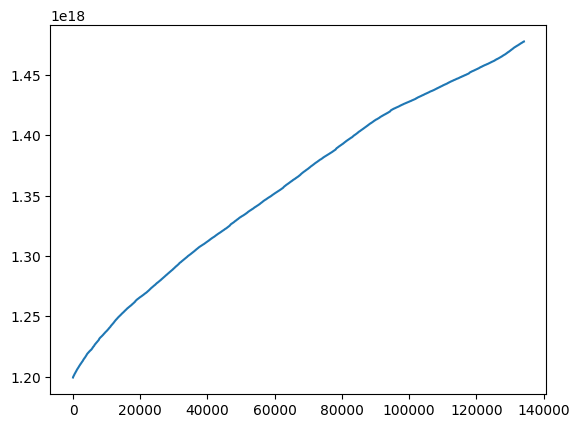

In [ ]:
# копируем столбец данных published
ser_data = train_df['published'].apply(lambda ts: pd.to_datetime(ts))
print('Ряд с датами столбца published')
print(ser_data.head())
print('Размер объекта Series: ', ser_data.shape)
ser_data.apply(lambda el: el.value).plot()

In [ ]:
corr = train_df.select_dtypes(include=[np.number]).corr()
corr

,post_id,content_len,comments,favs,views,votes_plus,votes_minus,views_lognorm,favs_lognorm,comments_lognorm
post_id,1.000000,0.241384,-0.147763,0.089313,0.132385,-0.187885,-0.235594,-0.010376,-0.005845,-0.001605
content_len,0.241384,1.000000,-0.023544,0.308194,0.204101,0.068779,-0.078686,0.246063,0.356481,0.073132
comments,-0.147763,-0.023544,1.000000,0.164166,0.290035,0.613961,0.457638,0.349568,0.278942,0.662740
favs,0.089313,0.308194,0.164166,1.000000,0.634304,0.416241,0.062877,0.456097,0.587982,0.263239
views,0.132385,0.204101,0.290035,0.634304,1.000000,0.396849,0.128654,0.585105,0.406782,0.326427
votes_plus,-0.187885,0.068779,0.613961,0.416241,0.396849,1.000000,0.464168,0.414232,0.449712,0.525081
votes_minus,-0.235594,-0.078686,0.457638,0.062877,0.128654,0.464168,1.000000,0.146609,0.088226,0.355458
views_lognorm,-0.010376,0.246063,0.349568,0.456097,0.585105,0.414232,0.146609,1.000000,0.688811,0.546530
favs_lognorm,-0.005845,0.356481,0.278942,0.587982,0.406782,0.449712,0.088226,0.688811,1.000000,0.479476
comments_lognorm,-0.001605,0.073132,0.662740,0.263239,0.326427,0.525081,0.355458,0.546530,0.479476,1.000000


In [ ]:
corr[corr>0.9].replace({np.nan : ''})

,post_id,content_len,comments,favs,views,votes_plus,votes_minus,views_lognorm,favs_lognorm,comments_lognorm
post_id,1.0,,,,,,,,,
content_len,,1.0,,,,,,,,
comments,,,1.0,,,,,,,
favs,,,,1.0,,,,,,
views,,,,,1.0,,,,,
votes_plus,,,,,,1.0,,,,
votes_minus,,,,,,,1.0,,,
views_lognorm,,,,,,,,1.0,,
favs_lognorm,,,,,,,,,1.0,
comments_lognorm,,,,,,,,,,1.0


In [ ]:
df = train_df.copy()
df['published'] = pd.to_datetime(df['published']).dt.year
ss = df['published'].value_counts()
print(ss.sort_index())

published
2008     7743
2009    10783
2010    13091
2011    15063
2012    15972
2013    15537
2014    16180
2015    23452
2016    16316
Name: count, dtype: int64


In [ ]:
features = ['author', 'flow', 'domain','title']
train_size = int(0.7 * train_df.shape[0])
print('Размер исходного набора: ', len(train_df), \
      '\nРазмер обучающей подвыборки: ', train_size)

# отделяем признаки от целевой переменной
X, y = train_df.loc[:, features], train_df['favs_lognorm']
X_test = test_df.loc[:, features]
X_train, X_valid = X.iloc[:train_size, :], X.iloc[train_size:, :]
y_train, y_valid = y.iloc[:train_size], y.iloc[train_size:]

Размер исходного набора:  134137 
Размер обучающей подвыборки:  93895


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_title = TfidfVectorizer(min_df=3, max_df=0.3, ngram_range=(1,3))

vx_train_title = vectorizer_title.fit_transform(X_train['title'])
print('vx_train_title.vocabulary_: ', len(vectorizer_title.vocabulary_))
vx_valid_title = vectorizer_title.transform(X_valid['title'])
print('vx_valid_title.vocabulary_: ', len(vectorizer_title.vocabulary_))
vx_test_title = vectorizer_title.transform(X_test['title'])
print('vx_test_title.vocabulary_: ', len(vectorizer_title.vocabulary_))

X_train_title = vectorizer_title.fit_transform(X_train['title'])
print('X_train_title.shape: ', X_train_title.shape)
X_valid_title = vectorizer_title.transform(X_valid['title'])
print('X_valid_title.shape: ', X_valid_title.shape)
X_test_title = vectorizer_title.transform(X_test['title'])
print('X_test_title.shape: ', X_test_title.shape)

vx_train_title.vocabulary_:  50624
vx_valid_title.vocabulary_:  50624
vx_test_title.vocabulary_:  50624
X_train_title.shape:  (93895, 50624)
X_valid_title.shape:  (40242, 50624)
X_test_title.shape:  (3990, 50624)


In [ ]:
vectorizer_title.vocabulary_

{'новогодний': 31497,
 'подарок': 36257,
 'блоггерам': 14241,
 'wordpress': 12172,
 'новогодний подарок': 31499,
 'сумасшедшие': 45476,
 'яйца': 50489,
 'или': 22661,
 'сервис': 42745,
 'для': 18811,
 'отслеживания': 34225,
 'посетителей': 37373,
 'или сервис': 22833,
 'сервис для': 42751,
 'для отслеживания': 19413,
 'или сервис для': 22834,
 'сервис для отслеживания': 42753,
 'сглаживание': 42460,
 'шрифтов': 49862,
 'отрисовка': 34214,
 'сглаживание шрифтов': 42461,
 'почему': 37632,
 'мне': 28231,
 'не': 30755,
 'нравится': 31925,
 'iphone': 5951,
 'почему мне': 37659,
 'мне не': 28233,
 'не нравится': 30851,
 'всеобщая': 16456,
 'доступность': 20285,
 'действии': 18272,
 'чем': 49165,
 'суть': 45504,
 'проекта': 39310,
 'ru': 9541,
 'search': 9842,
 'запускается': 21584,
 'понедельник': 37201,
 'mobile': 7315,
 'выбор': 16759,
 'способа': 44575,
 'связи': 42437,
 'обзор': 32095,
 'под': 36147,
 'windows': 11973,
 'под windows': 36185,
 'онлайн': 33063,
 'банкинг': 13661,
 'оформле

In [ ]:
vectorizer_title_ch = TfidfVectorizer(analyzer='char')

vx_train_title_ch = vectorizer_title_ch.fit_transform(X_train['title'])
print('vx_train_title_ch.vocabulary_: ', len(vectorizer_title_ch.vocabulary_))

vx_valid_title_ch = vectorizer_title_ch.transform(X_valid['title'])
print('vx_valid_title_ch.vocabulary_: ', len(vectorizer_title_ch.vocabulary_))

vx_test_title_ch = vectorizer_title_ch.transform(X_test['title'])
print('vx_test_title_ch.vocabulary_: ', len(vectorizer_title_ch.vocabulary_))

X_train_title_ch = vectorizer_title_ch.fit_transform(X_train['title'])
print('X_train_title_ch.shape: ', X_train_title_ch.shape)
X_valid_title_ch = vectorizer_title_ch.transform(X_valid['title'])
print('X_valid_title_ch.shape: ', X_valid_title_ch.shape)
X_test_title_ch = vectorizer_title_ch.transform(X_test['title'])
print('X_test_title_ch.shape: ', X_test_title_ch.shape)

vx_train_title_ch.vocabulary_:  218
vx_valid_title_ch.vocabulary_:  218
vx_test_title_ch.vocabulary_:  218
X_train_title_ch.shape:  (93895, 218)
X_valid_title_ch.shape:  (40242, 218)
X_test_title_ch.shape:  (3990, 218)


In [ ]:
from sklearn.feature_extraction import DictVectorizer
vectorizer_feats = DictVectorizer()

tmp_dict_train = X_train[features].fillna('-').T.to_dict().values()
tmp_dict_valid = X_valid[features].fillna('-').T.to_dict().values()
tmp_dict_test = X_test[features].fillna('-').T.to_dict().values()

X_train_feats = vectorizer_feats.fit_transform(tmp_dict_train)
X_valid_feats = vectorizer_feats.transform(tmp_dict_valid)
X_test_feats = vectorizer_feats.transform(tmp_dict_test)

print(X_train_feats.shape)
print(X_valid_feats.shape)
print(X_test_feats.shape)

(93895, 111482)
(40242, 111482)
(3990, 111482)


In [ ]:
# объединение матриц, построенных на предыдущих этапах
X_train_new = scipy.sparse.hstack([X_train_title, \
                                   X_train_feats, \
                                   X_train_title_ch])
X_valid_new = scipy.sparse.hstack([X_valid_title, \
                                   X_valid_feats, \
                                   X_valid_title_ch])
X_test_new = scipy.sparse.hstack([X_test_title, \
                                  X_test_feats, \
                                  X_test_title_ch])

print(X_train_new.shape)
print(X_valid_new.shape)
print(X_test_new.shape)

(93895, 162324)
(40242, 162324)
(3990, 162324)


In [ ]:
%%time
model_1 = Ridge(alpha=.1, random_state=1)
model_1.fit(X_train_new, y_train)

train_preds1 = model_1.predict(X_train_new)
valid_preds1 = model_1.predict(X_valid_new)

print('Ошибка на трейне: ', mean_squared_error(y_train, train_preds1))
print('Ошибка на тесте: ', mean_squared_error(y_valid, valid_preds1))

Ошибка на трейне:  0.0033498668127804505
Ошибка на тесте:  0.6982987113454213
CPU times: user 43.8 s, sys: 32.2 ms, total: 43.8 s
Wall time: 38.6 s


In [ ]:
%%time
model_2 = Ridge(alpha=1.0, random_state=1)
model_2.fit(X_train_new, y_train)

train_preds2 = model_2.predict(X_train_new)
valid_preds2 = model_2.predict(X_valid_new)

print('Ошибка на трейне: ', mean_squared_error(y_train, train_preds2))
print('Ошибка на тесте: ', mean_squared_error(y_valid, valid_preds2))

Ошибка на трейне:  0.08633264425668048
Ошибка на тесте:  0.6840061221431166
CPU times: user 15.2 s, sys: 15.5 ms, total: 15.2 s
Wall time: 9.23 s


Размер датасета: (20640, 9)
Первые 5 строк:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  


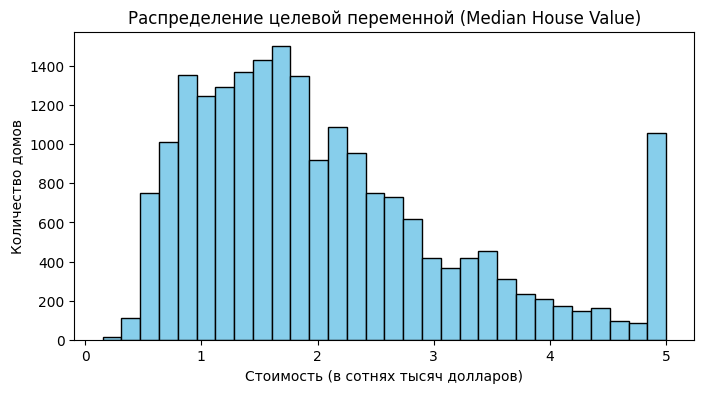

In [ ]:
from __future__ import division, print_function
import numpy as np
import pandas as pd
import scipy
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

%matplotlib inline

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Target'] = housing.target

print("Размер датасета:", df.shape)
print("Первые 5 строк:")
print(df.head())

plt.figure(figsize=(8, 4))
plt.hist(df['Target'], bins=30, color='skyblue', edgecolor='black')
plt.title('Распределение целевой переменной (Median House Value)')
plt.xlabel('Стоимость (в сотнях тысяч долларов)')
plt.ylabel('Количество домов')
plt.show()

In [ ]:
X = df.drop('Target', axis=1).values
y = df['Target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Размер обучающей выборки:\t', X_train.shape)
print('Размер тестовой выборки:\t', X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Размер обучающей выборки:	 (16512, 8)
Размер тестовой выборки:	 (4128, 8)


In [ ]:

model_1 = Ridge(alpha=0.1, random_state=42)
model_1.fit(X_train_scaled, y_train)
train_preds1 = model_1.predict(X_train_scaled)
test_preds1 = model_1.predict(X_test_scaled)

print('Модель 1')
print('MSE на обучении:', mean_squared_error(y_train, train_preds1))
print('MSE на тесте:', mean_squared_error(y_test, test_preds1))
print('\n')

model_2 = Ridge(alpha=1.0, random_state=42)
model_2.fit(X_train_scaled, y_train)
train_preds2 = model_2.predict(X_train_scaled)
test_preds2 = model_2.predict(X_test_scaled)

print('Модель 2')
print('MSE на обучении:', mean_squared_error(y_train, train_preds2))
print('MSE на тесте:', mean_squared_error(y_test, test_preds2))

Модель 1
MSE на обучении: 0.5179331264555785
MSE на тесте: 0.5558879138674184


Модель 2
MSE на обучении: 0.5179332184751891
MSE на тесте: 0.5558548589435974


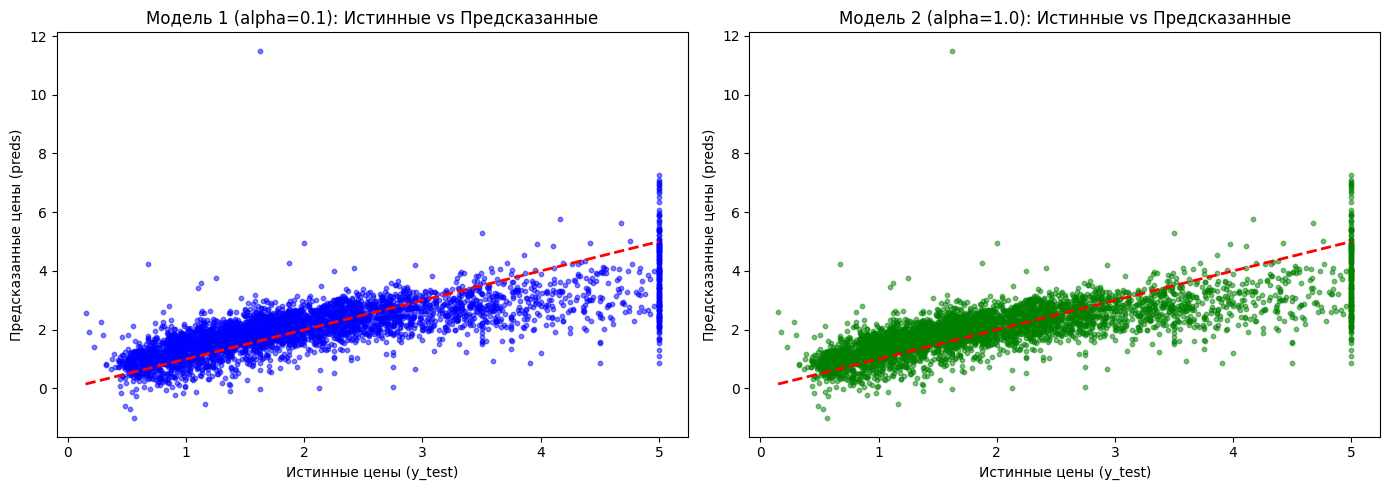

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, test_preds1, alpha=0.5, color='blue', s=10)
# Диагональная линия (идеальное предсказание)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', linewidth=2)
plt.xlabel('Истинные цены (y_test)')
plt.ylabel('Предсказанные цены (preds)')
plt.title('Модель 1 (alpha=0.1): Истинные vs Предсказанные')

plt.subplot(1, 2, 2)
plt.scatter(y_test, test_preds2, alpha=0.5, color='green', s=10)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', linewidth=2)
plt.xlabel('Истинные цены (y_test)')
plt.ylabel('Предсказанные цены (preds)')
plt.title('Модель 2 (alpha=1.0): Истинные vs Предсказанные')

plt.tight_layout()
plt.show()